# 准备数据

In [1]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [3]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi1000")

In [4]:
# 设置任务参数
name = "lasso"
index_symbol: str = "000852.SSE"
start: str = "2016-01-01"
end: str = "2025-12-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [5]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [6]:
# 加载模块
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_cs_norm,
    process_fill_na
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [7]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [8]:
df

datetime,open,high,low,close,volume,turnover,open_interest,vwap,vt_symbol
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,str
2015-09-23 00:00:00,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,"""600978.SSE"""
2015-09-24 00:00:00,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,"""600978.SSE"""
2015-09-25 00:00:00,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,"""600978.SSE"""
2015-09-28 00:00:00,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,"""600978.SSE"""
2015-09-29 00:00:00,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,"""600978.SSE"""
…,…,…,…,…,…,…,…,…,…
2026-01-05 00:00:00,2.185029,2.229492,2.096103,2.13739,3.6019418e7,2.42730085e8,0.0,6.738867,"""600966.SSE"""
2026-01-06 00:00:00,2.124686,2.175501,2.102455,2.140566,1.8993499e7,1.2820914e8,0.0,6.750159,"""600966.SSE"""
2026-01-07 00:00:00,2.143742,2.178677,2.12151,2.146918,1.8716994e7,1.26683061e8,0.0,6.768344,"""600966.SSE"""


In [9]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period=("2016-01-01", "2020-12-31"),
    valid_period=("2021-01-01", "2022-12-31"),
    test_period=("2023-01-01", "2025-12-31"),
)

In [10]:
# 添加数据预处理器
dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_norm, names=["label"], method="zscore"))

dataset.add_processor("infer", partial(process_fill_na, fill_value=0))

In [11]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [12]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=3)

# 应用数据预处理器
dataset.process_data()

2026-06-30 14:44:35 开始计算表达式因子特征


100%|██████████| 159/159 [2:59:51<00:00, 67.87s/it]   


2026-06-30 17:44:30 开始合并结果数据因子特征


0it [00:00, ?it/s]


2026-06-30 17:44:35 开始筛选成分股数据


100%|██████████| 2637/2637 [00:30<00:00, 85.09it/s] 


Dropped 6.3% entries from factor data: 0.4% in forward returns computation and 5.8% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,0.000000,0.925373,0.089777,0.115886,227800,10.000009
2.0,0.001028,0.942598,0.213690,0.163548,227800,10.000009
3.0,0.011581,0.965429,0.295325,0.187973,227800,10.000009
4.0,0.019260,0.976284,0.365490,0.200740,227800,10.000009
5.0,0.026252,0.984252,0.432782,0.205994,227800,10.000009
6.0,0.033613,0.990599,0.501374,0.204910,227798,9.999921
7.0,0.044639,1.000000,0.574352,0.197252,227800,10.000009
8.0,0.062500,1.000000,0.655948,0.181126,227800,10.000009
9.0,0.094397,1.000000,0.752352,0.152965,227800,10.000009


Returns Analysis


,1D,5D,10D
Ann. alpha,0.029,-0.022,-0.006
beta,-0.034,-0.022,-0.015
Mean Period Wise Return Top Quantile (bps),5.166,-2.908,-1.834
Mean Period Wise Return Bottom Quantile (bps),-3.653,-2.376,-2.382
Mean Period Wise Spread (bps),8.819,-0.493,0.574


<Figure size 640x480 with 0 Axes>

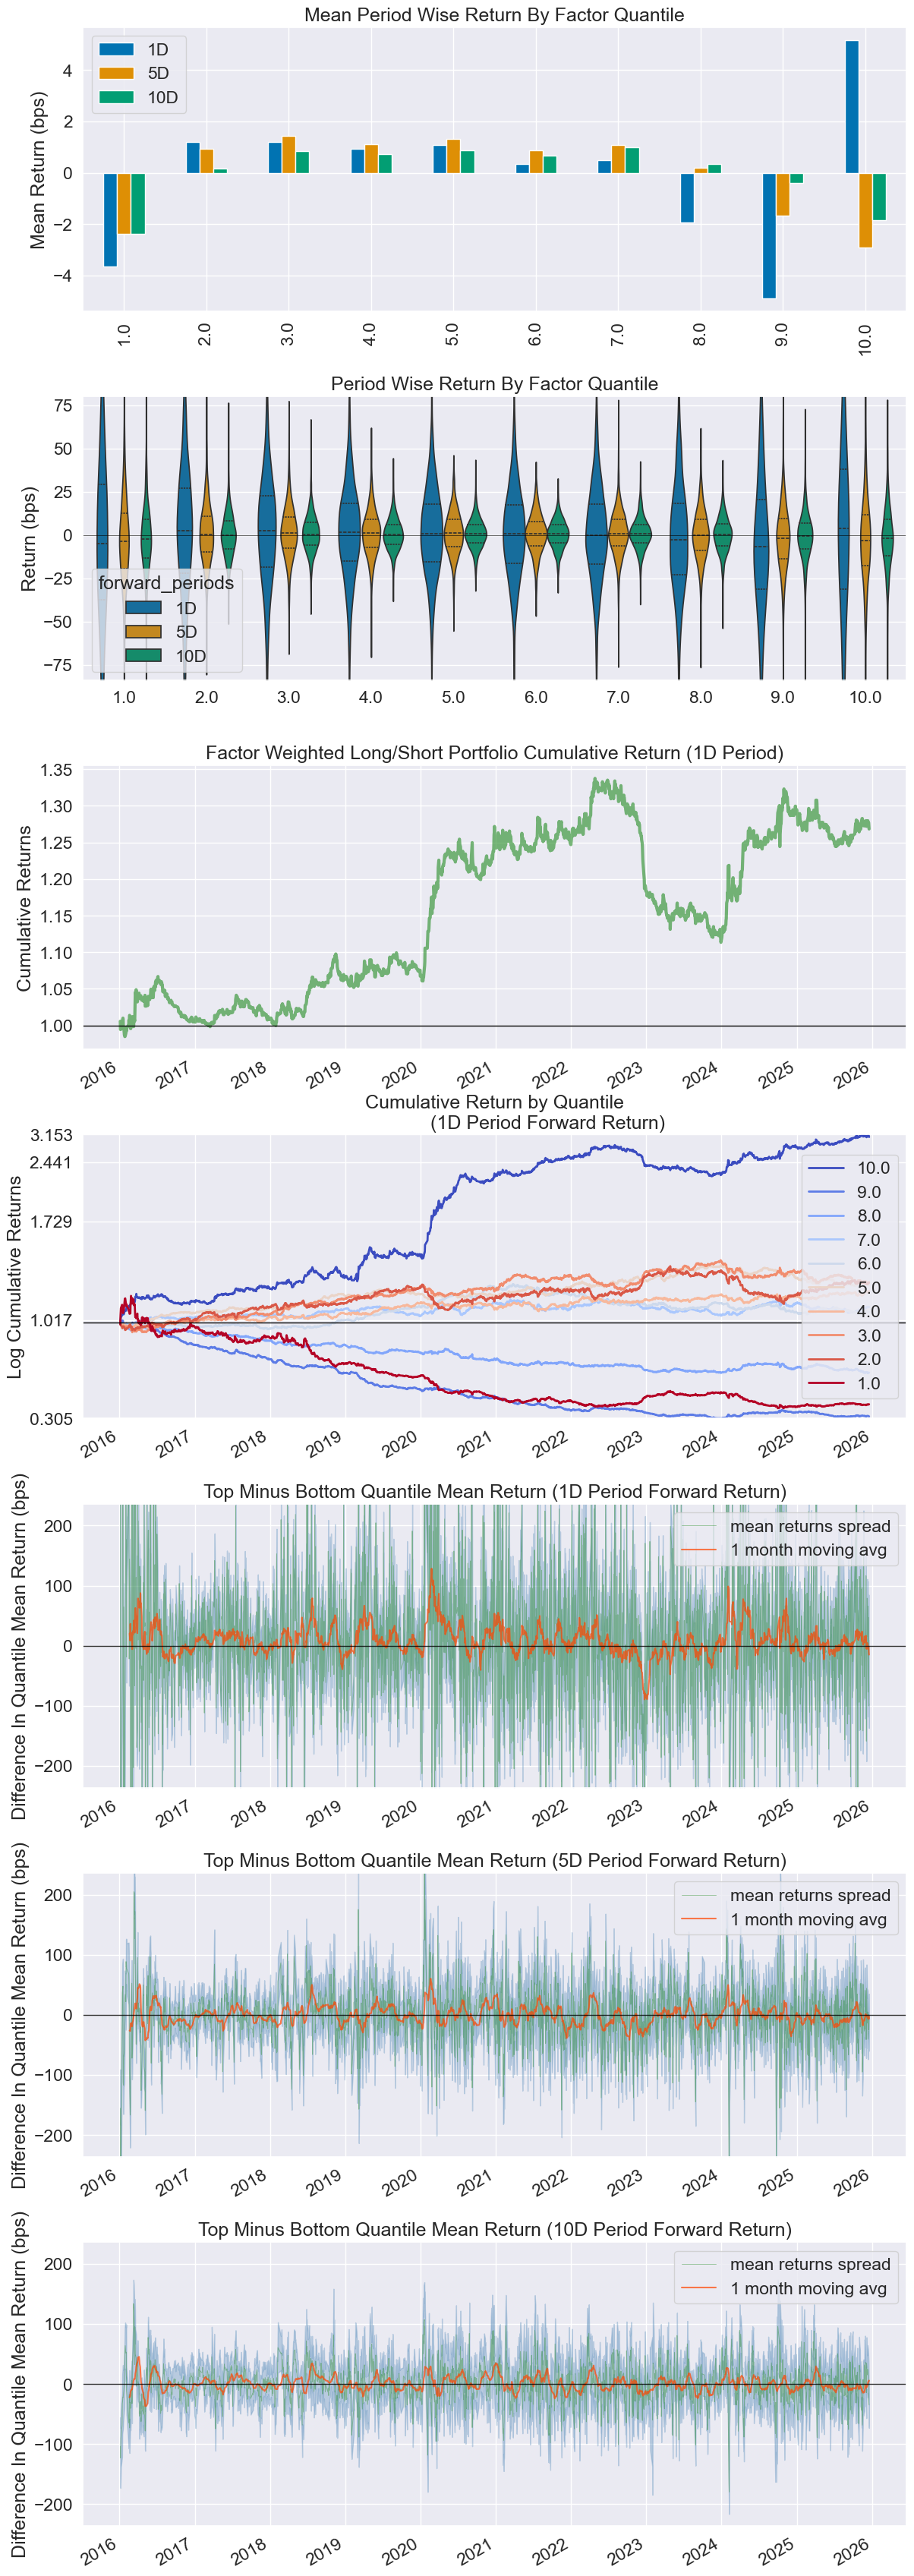

Information Analysis


,1D,5D,10D
IC Mean,-0.031,-0.017,-0.010
IC Std.,0.140,0.124,0.121
Risk-Adjusted IC,-0.219,-0.136,-0.079
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


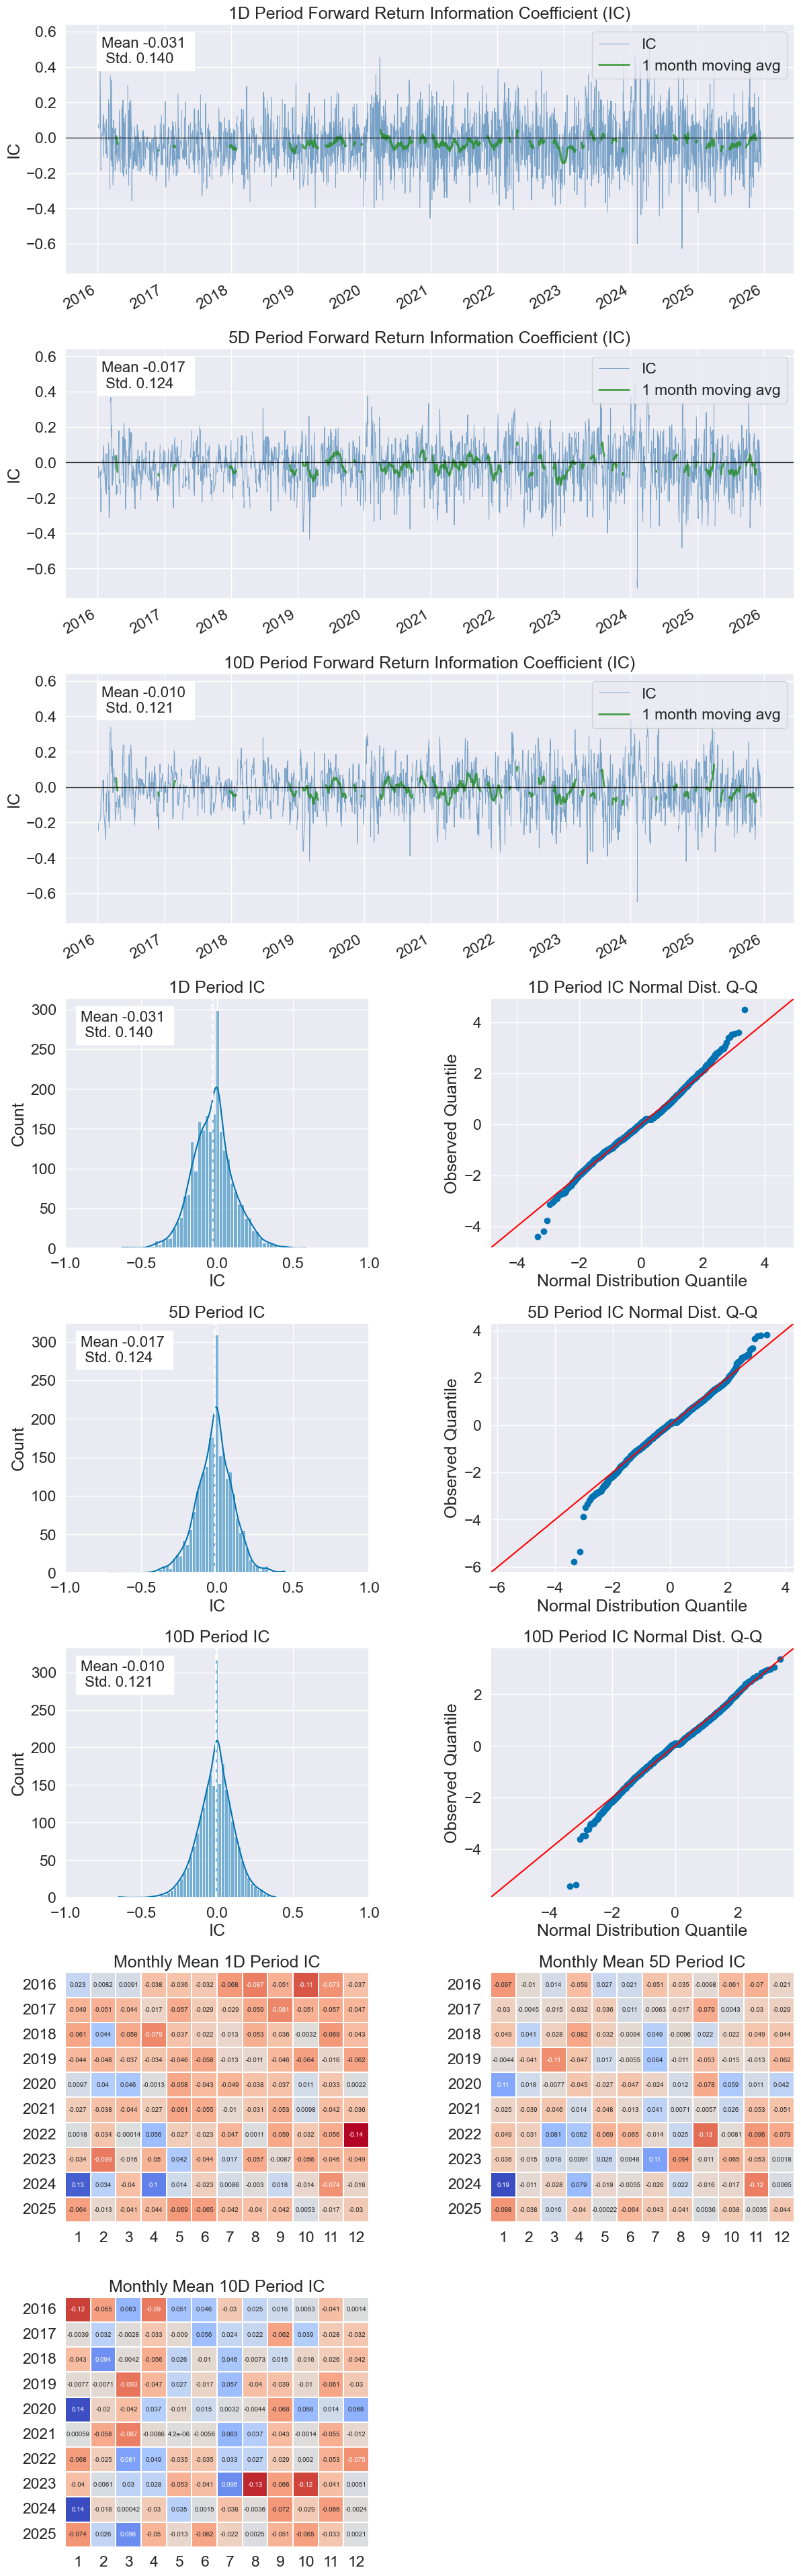

d:\veighna_studio\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.553,0.773,0.781
Quantile 2.0 Mean Turnover,0.759,0.902,0.900
Quantile 3.0 Mean Turnover,0.821,0.898,0.899
Quantile 4.0 Mean Turnover,0.847,0.896,0.897
Quantile 5.0 Mean Turnover,0.858,0.895,0.896
Quantile 6.0 Mean Turnover,0.859,0.896,0.897
Quantile 7.0 Mean Turnover,0.854,0.897,0.899
Quantile 8.0 Mean Turnover,0.836,0.900,0.900
Quantile 9.0 Mean Turnover,0.793,0.899,0.898
Quantile 10.0 Mean Turnover,0.684,0.897,0.893


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.596,0.015,0.031


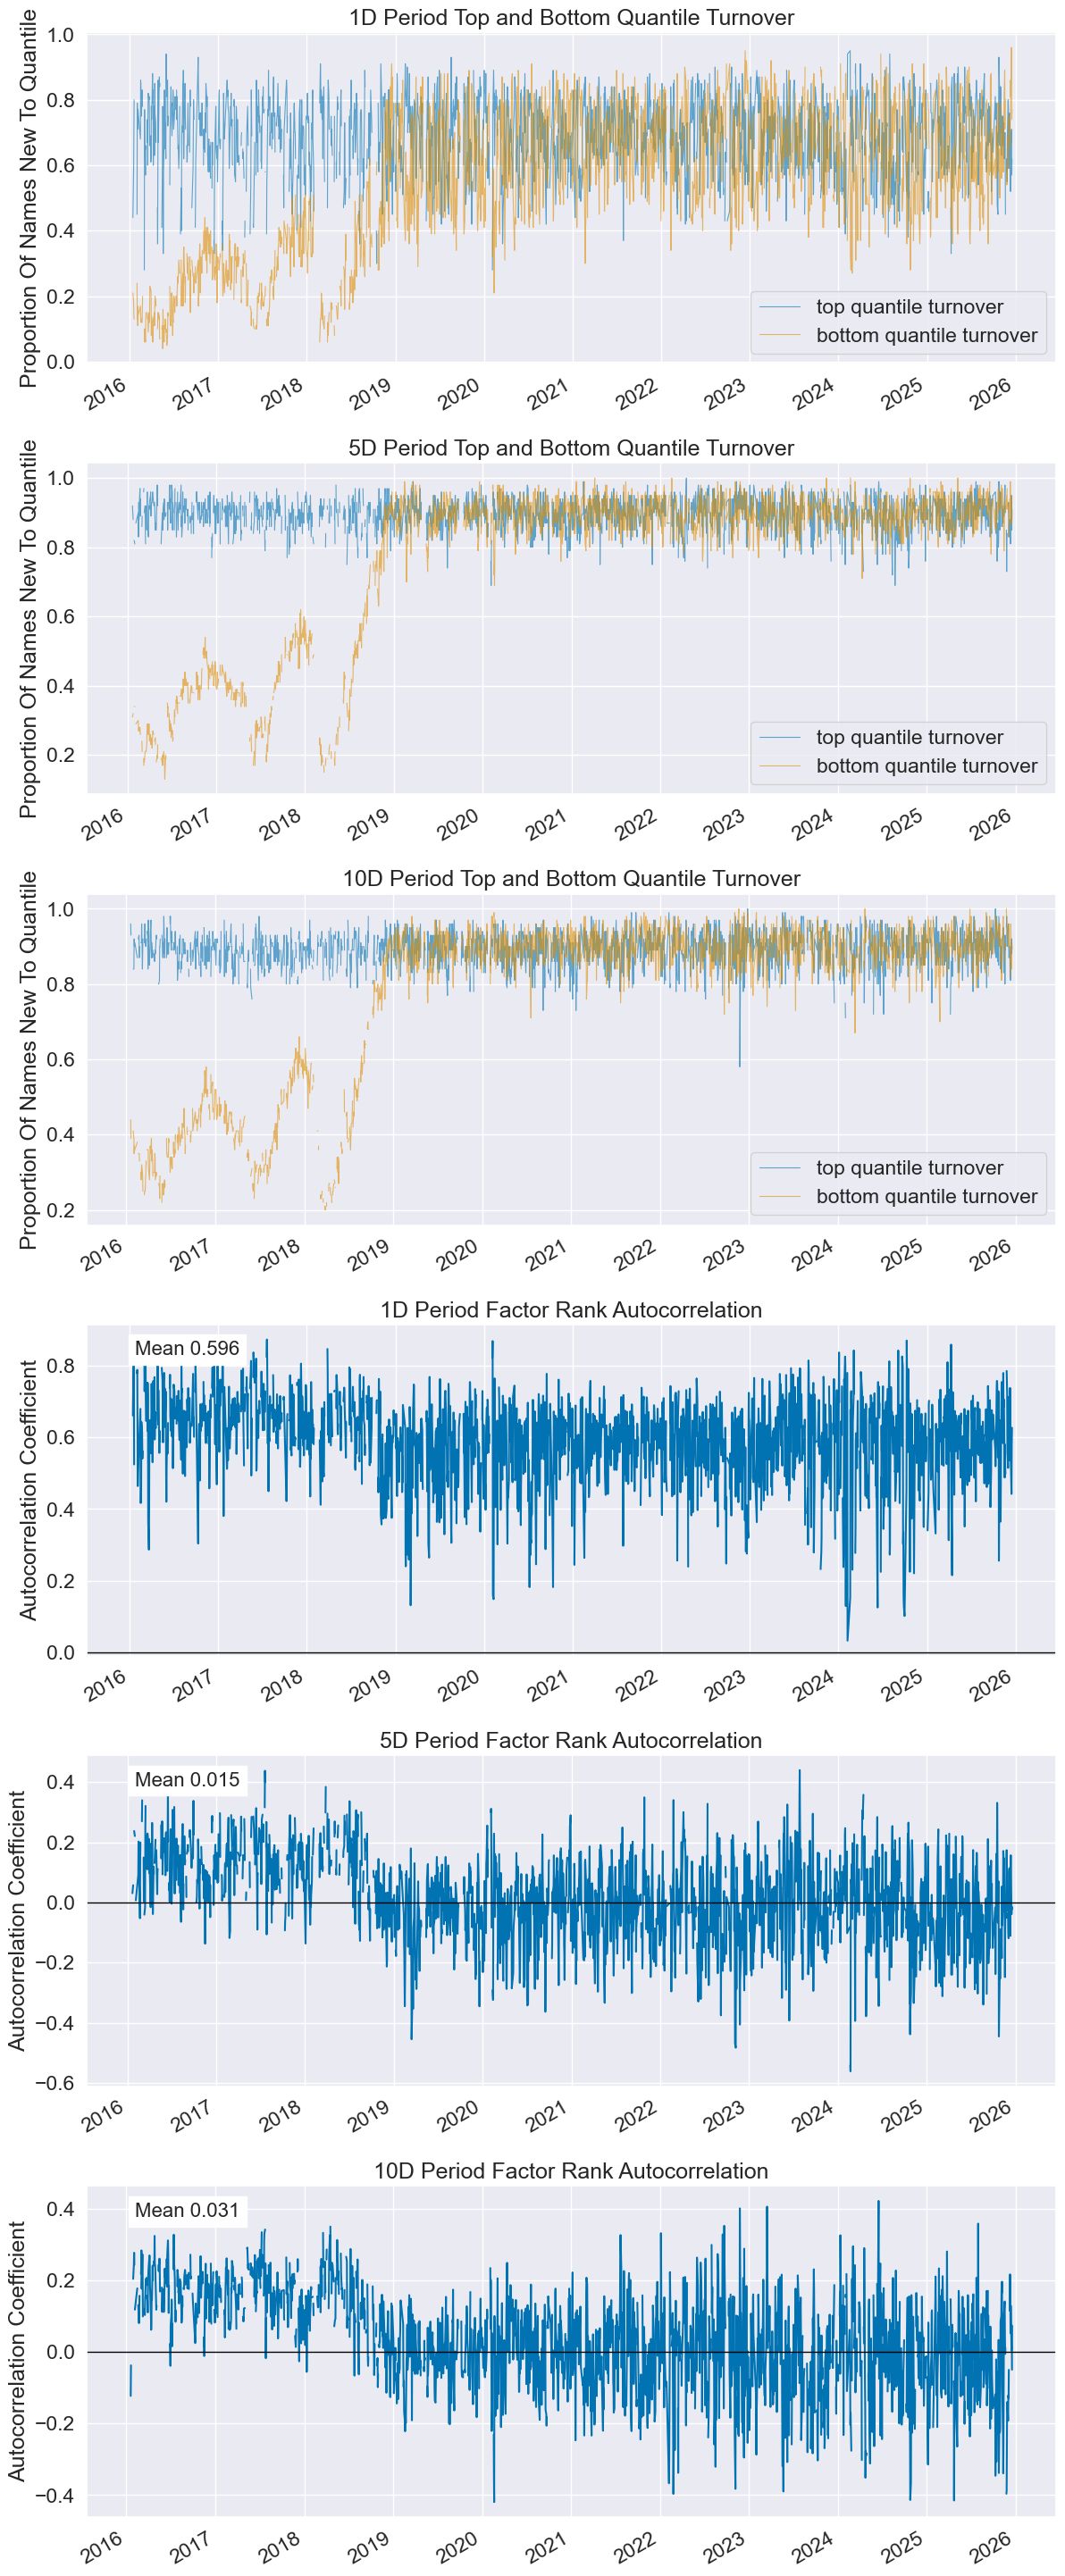

In [13]:
# 特征表现分析
dataset.show_feature_performance("rsv_5")

# 模型训练

In [16]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.lasso_model import LassoModel

In [18]:
# 创建模型对象
model: AlphaModel = LassoModel()

In [19]:
# 使用数据集训练模型
model.fit(dataset)

d:\veighna_studio\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.496e+05, tolerance: 1.701e+02
  model = cd_fast.enet_coordinate_descent(


In [20]:
# 查看模型细节
model.detail()

2026-06-30 17:58:55 LASSO模型特征总数量: 45
2026-06-30 17:58:55 max_5: -0.103567
2026-06-30 17:58:55 roc_60: 0.055389
2026-06-30 17:58:55 rsv_60: 0.054408
2026-06-30 17:58:55 rsv_20: 0.045513
2026-06-30 17:58:55 roc_20: 0.045418
2026-06-30 17:58:55 min_60: 0.039339
2026-06-30 17:58:55 imxd_5: -0.032211
2026-06-30 17:58:55 rsv_30: 0.029476
2026-06-30 17:58:55 rank_5: -0.029231
2026-06-30 17:58:55 imax_30: -0.025639
2026-06-30 17:58:55 rsv_10: 0.022623
2026-06-30 17:58:55 cord_20: -0.020479
2026-06-30 17:58:55 wvma_60: -0.020069
2026-06-30 17:58:55 qtlu_60: 0.019440
2026-06-30 17:58:55 ksft_2: -0.017672
2026-06-30 17:58:55 cord_10: -0.015523
2026-06-30 17:58:55 cntn_5: -0.014802
2026-06-30 17:58:55 imin_60: -0.011578
2026-06-30 17:58:55 wvma_30: -0.010985
2026-06-30 17:58:55 cord_30: -0.010875
2026-06-30 17:58:55 rsqr_5: -0.009367
2026-06-30 17:58:55 rsqr_30: -0.008743
2026-06-30 17:58:55 sumd_10: 0.008387
2026-06-30 17:58:55 sump_10: 0.006651
2026-06-30 17:58:55 imxd_20: -0.006238
2026-06-30 1

In [21]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [22]:
model: AlphaModel = lab.load_model(name)

In [23]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

Dropped 1.4% entries from factor data: 1.4% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-2.392443,0.012038,-0.075689,0.040417,71700,10.0
2,-0.127301,0.034744,-0.039050,0.017311,71700,10.0
3,-0.109585,0.048425,-0.024791,0.017252,71700,10.0
4,-0.096380,0.061363,-0.014278,0.017378,71700,10.0
5,-0.085485,0.073512,-0.005376,0.017498,71700,10.0
6,-0.079041,0.084971,0.002883,0.017624,71700,10.0
7,-0.071525,0.095306,0.011146,0.017681,71700,10.0
8,-0.064169,0.105178,0.020090,0.017674,71700,10.0
9,-0.056047,0.114882,0.030979,0.017713,71700,10.0


Returns Analysis


,1D,5D,10D
Ann. alpha,0.125,0.110,0.093
beta,-0.087,-0.073,-0.075
Mean Period Wise Return Top Quantile (bps),4.105,3.315,2.979
Mean Period Wise Return Bottom Quantile (bps),-9.056,-7.870,-6.251
Mean Period Wise Spread (bps),13.161,11.225,9.249


<Figure size 640x480 with 0 Axes>

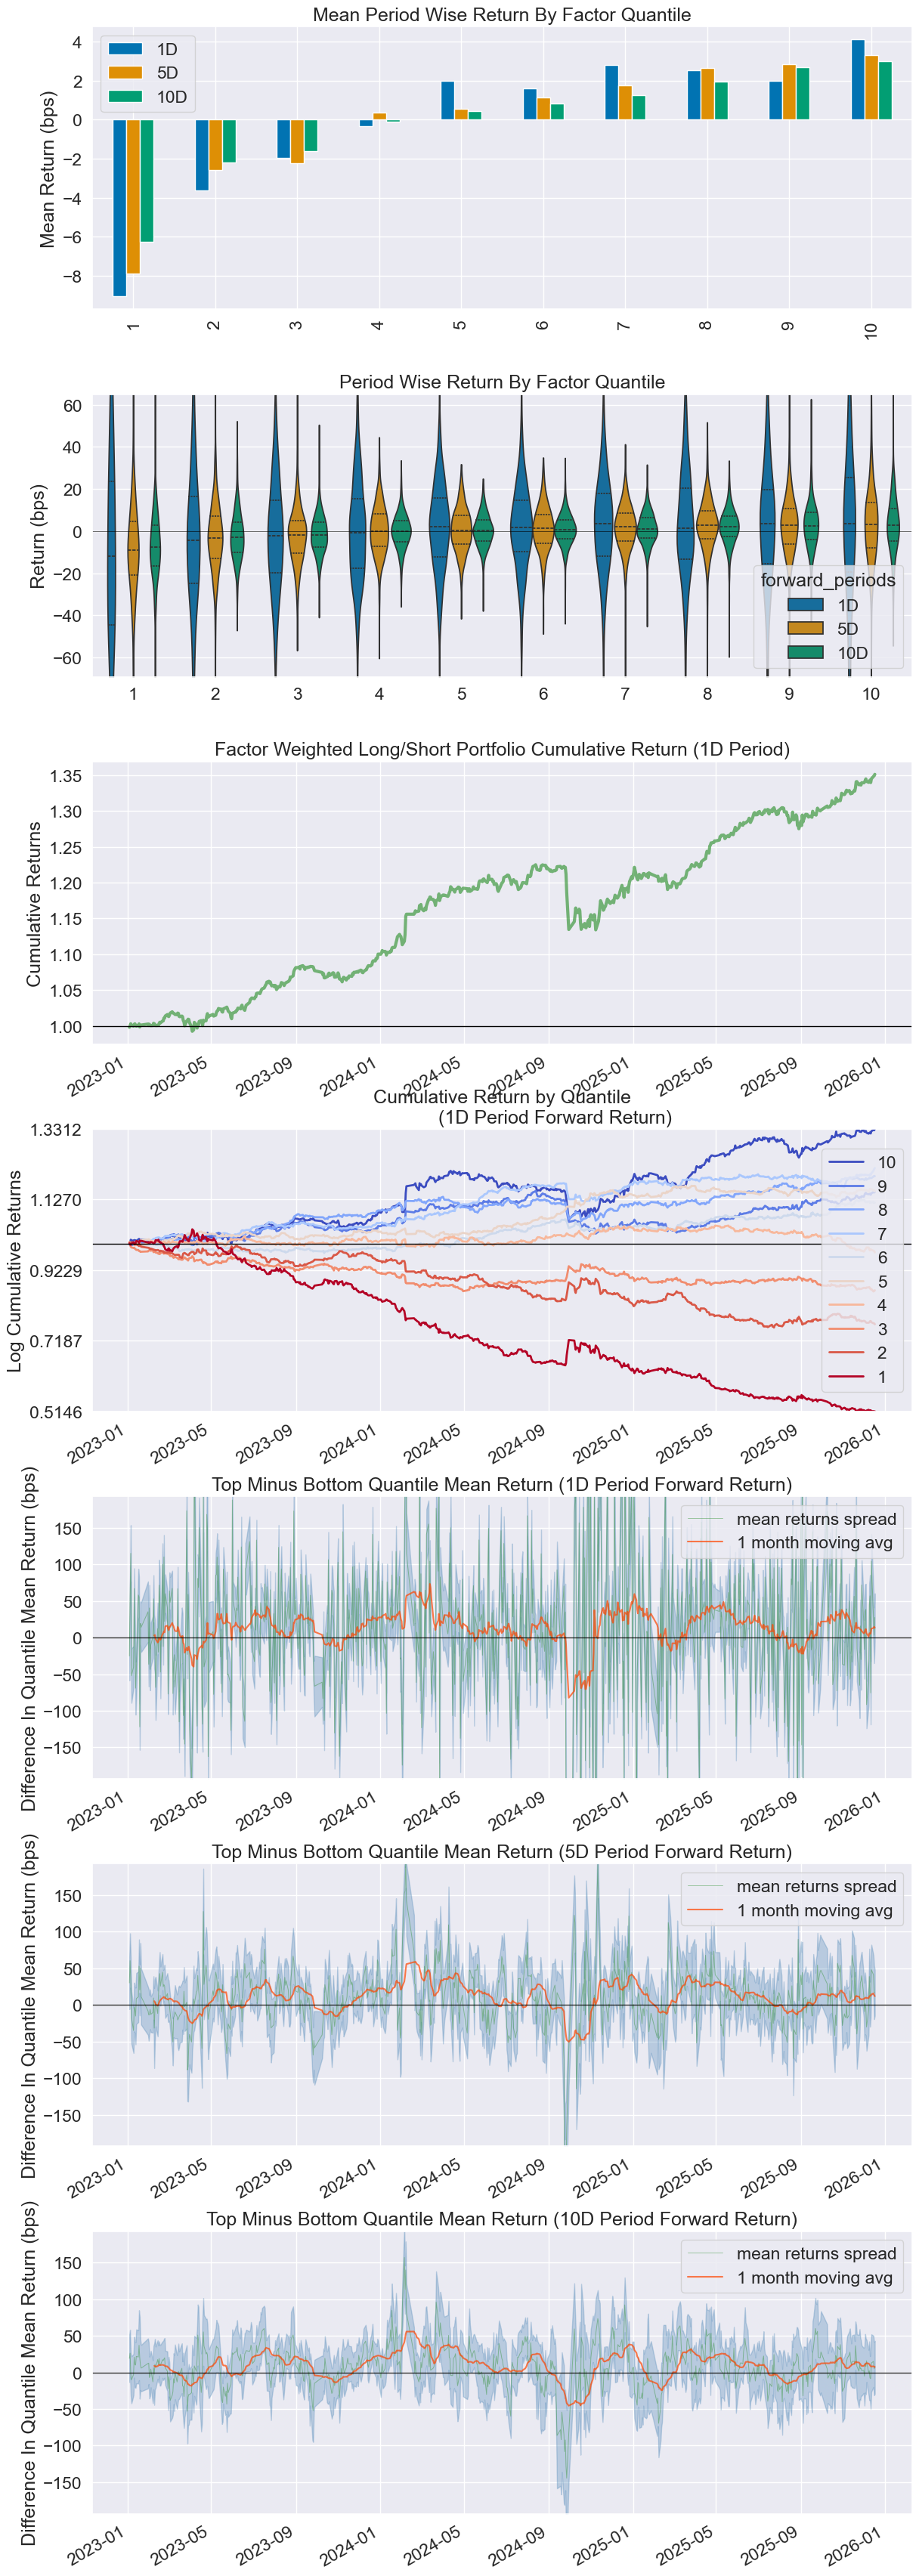

Information Analysis


,1D,5D,10D
IC Mean,0.047,0.060,0.067
IC Std.,0.109,0.101,0.104
Risk-Adjusted IC,0.432,0.596,0.643
t-stat(IC),11.563,15.960,17.205
p-value(IC),0.000,0.000,0.000
IC Skew,-0.420,0.096,-0.026
IC Kurtosis,1.550,1.333,0.758


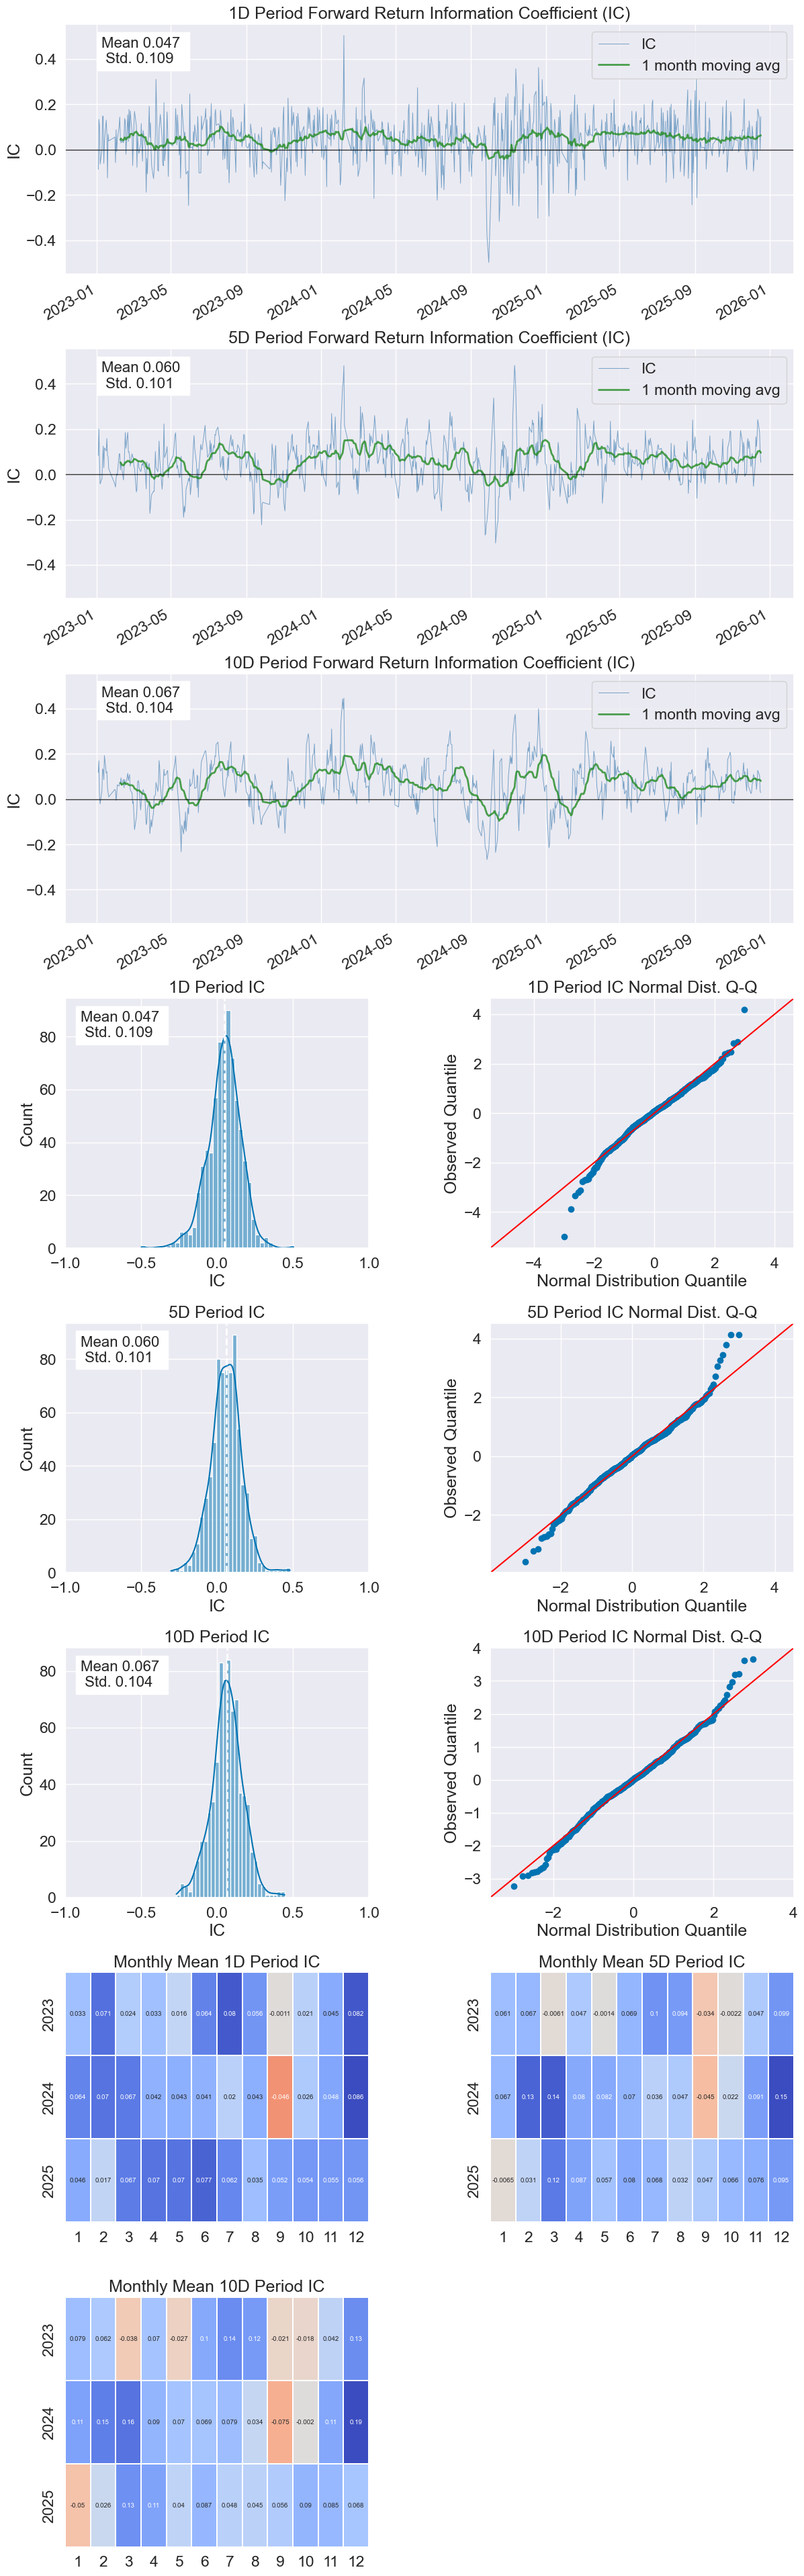

d:\veighna_studio\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.288,0.496,0.570
Quantile 2 Mean Turnover,0.620,0.783,0.814
Quantile 3 Mean Turnover,0.727,0.839,0.860
Quantile 4 Mean Turnover,0.771,0.860,0.874
Quantile 5 Mean Turnover,0.791,0.867,0.883
Quantile 6 Mean Turnover,0.797,0.871,0.881
Quantile 7 Mean Turnover,0.790,0.867,0.877
Quantile 8 Mean Turnover,0.766,0.854,0.869
Quantile 9 Mean Turnover,0.701,0.818,0.839
Quantile 10 Mean Turnover,0.419,0.668,0.737


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.835,0.579,0.473


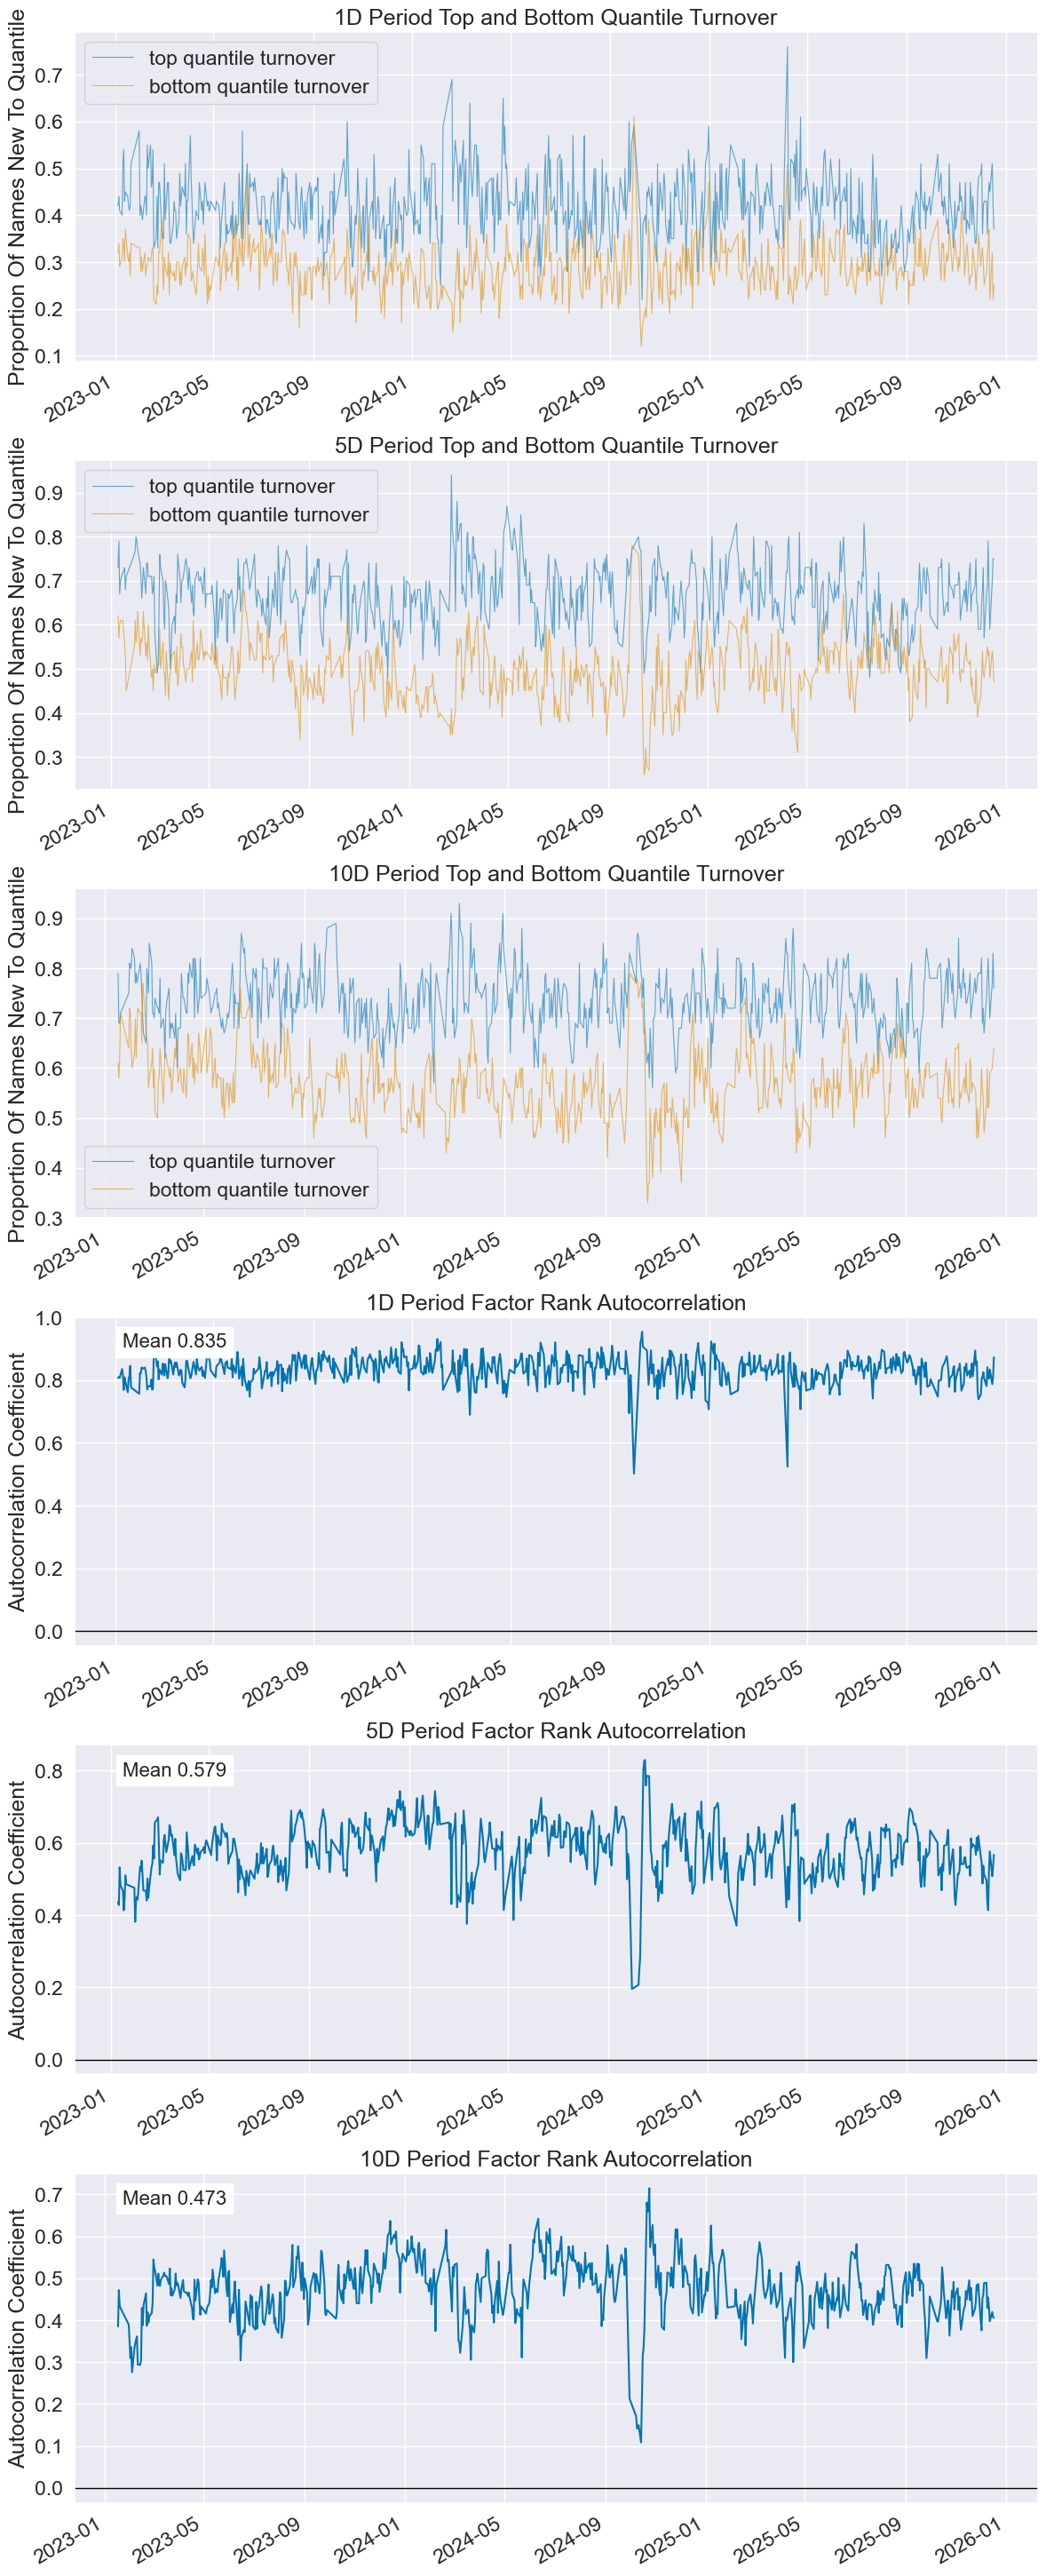

In [24]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [25]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [26]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [27]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [28]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [31]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2023, 1, 1),
    end=datetime(2025, 12, 31),
    capital=100_000_000
)

# 添加策略实例
setting = {"top_k": 225, "n_drop": 20, "min_days": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [32]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2026-06-30 18:04:09 开始加载历史数据


100%|██████████| 2637/2637 [00:23<00:00, 110.75it/s]

2026-06-30 18:04:33 部分合约历史数据为空：['600978.SSE', '002359.SZSE', '300431.SZSE', '002680.SZSE', '002619.SZSE', '002147.SZSE', '600687.SSE', '300156.SZSE', '002711.SZSE', '000022.SZSE', '300216.SZSE', '600723.SSE', '300362.SZSE', '600555.SSE', '300038.SZSE', '000662.SZSE', '002509.SZSE', '600146.SSE', '002070.SZSE', '002071.SZSE', '600677.SSE', '300312.SZSE', '000018.SZSE', '000916.SZSE', '000760.SZSE', '002447.SZSE', '600069.SSE', '600090.SSE', '600634.SSE', '002143.SZSE', '000673.SZSE', '600401.SSE', '600701.SSE', '600856.SSE', '601313.SSE', '002618.SZSE', '000687.SZSE', '300367.SZSE', '603996.SSE', '600275.SSE', '600093.SSE', '600680.SSE', '600652.SSE', '300064.SZSE', '300028.SZSE', '002604.SZSE', '600291.SSE', '300178.SZSE', '000043.SZSE', '600175.SSE', '002260.SZSE', '002464.SZSE', '300090.SZSE', '600209.SSE', '002684.SZSE']
2026-06-30 18:04:33 所有历史数据加载完成
2026-06-30 18:04:33 策略初始化完成
2026-06-30 18:04:33 开始回放历史数据


2026-06-30 18:04:51 历史数据回放结束
2026-06-30 18:04:51 开始计算逐日盯市盈亏
2026-06-30 18:04:54 逐日盯市盈亏计算完成
2026-06-30 18:04:54 开始计算策略统计指标
2026-06-30 18:04:54 ------------------------------
2026-06-30 18:04:54 首个交易日：  2023-01-03
2026-06-30 18:04:54 最后交易日：  2025-12-31
2026-06-30 18:04:54 总交易日：  727
2026-06-30 18:04:54 盈利交易日：  396
2026-06-30 18:04:54 亏损交易日：  330
2026-06-30 18:04:54 起始资金：  100,000,000.00
2026-06-30 18:04:54 结束资金：  153,945,002.99
2026-06-30 18:04:54 总收益率：  53.95%
2026-06-30 18:04:54 年化收益：  17.81%
2026-06-30 18:04:54 最大回撤:   -39,725,126.90
2026-06-30 18:04:54 百分比最大回撤: -35.62%
2026-06-30 18:04:54 最长回撤天数:   356
2026-06-30 18:04:54 总盈亏：  53,945,002.99
2026-06-30 18:04:54 总手续费：  9,478,369.28
2026-06-30 18:04:54 总成交金额：  12,667,765,835.39
2026-06-30 18:04:54 总成交笔数：  25698
2026-06-30 18:04:54 日均盈亏：  74,202.20
2026-06-30 18:04:54 日均手续费：  13,037.65
2026-06-30 18:04:54 日均成交金额：  17,424,712.29
2026-06-30 18:04:54 日均成交笔数：  35.34800550206327
2026-06-30 18:04:54 日均收益率：  0.07%
2026-06-30 18:04:54 收益标准差：  1

In [33]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)